In [3]:
import pandas as pd

# Load DataFrame from pickle file
df = pd.read_pickle("feature_files/sim_features_large5_2025-07-22")
# df = pd.read_pickle("feature_files/features_saved_on_2025-07-12.pkl")
df = df.dropna()


# Ensure Date is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Sort DataFrame by Date
df = df.sort_values(by='Date')

# Define target (y) and features (X)
y = df['Price']
X = df.drop(columns=['Price', 'Date']) # Exclude Date from features

# Print shapes to verify
print(f"X: {X.shape}")
print(f"y: {y.shape}")

X: (4131, 41)
y: (4131,)


In [4]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from scipy.stats import skew, kurtosis, jarque_bera
import numpy as np
import pickle


def fit_gpr_model(X, y, save_path="models/gpr_full_model.pkl", random_state=42):  
    
    kernel = C(1.0, (1e-2, 1e4)) * RBF(length_scale=1.0, length_scale_bounds= (1e-4, 1e3)) + WhiteKernel(noise_level=1e-2, noise_level_bounds= (1e-10, 1e1))

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", GaussianProcessRegressor(
            kernel=kernel,
            normalize_y=True,
            random_state=random_state
        ))
    ])

    model.fit(X, y)

    with open(save_path, "wb") as f:
        pickle.dump(model, f)

    predictions = model.predict(X)

    metrics = {
        "Average Absolute Error": mean_absolute_error(y, predictions),
        "Maximum Absolute Error": np.max(np.abs(y - predictions)),
        "MSE": mean_squared_error(y, predictions),
        "Root Mean Squared Error": root_mean_squared_error(y, predictions),
        "Adjusted MAPE (%)": np.mean(np.abs((y - predictions) / (max(y) - min(y)))) * 100,
        "Out of Sample R2": r2_score(y, predictions)}

    return model, metrics

In [ ]:
best_model, metrics = fit_gpr_model(X, y, save_path="models/gpr_full_model_tuned6.pkl")

print("========== in-sample =============")
print(metrics)

========== in-sample =============
{'Average Absolute Error': 0.4908437661231349, 'Maximum Absolute Error': 23.594549834516904, 'MSE': 1.1453118964236353, 'Root Mean Squared Error': 1.070192457655928, 'Adjusted MAPE (%)': 0.8069514901513065, 'Out of Sample R2': 0.9481519268759552}


In [10]:
# fitted pipeline returned by fit_gpr_model
gpr = best_model.named_steps["regressor"]     # the GPR object
opt_kernel = gpr.kernel_                      # instance of Constant * RBF + White

print(opt_kernel)
# Example output:
# 0.83**2 * RBF(length_scale=2.41) + WhiteKernel(noise_level=0.0072)

# ----- extract individual hyper‑parameters ---------------------------
const_value  = opt_kernel.k1.k1.constant_value        # 0.83**2 → constant σ_f²
length_scale = opt_kernel.k1.k2.length_scale          # 2.41
noise_level  = opt_kernel.k2.noise_level              # 0.0072

print("σ_f² :", const_value)
print("ℓ     :", length_scale)
print("σ_n² :", noise_level)

15.5**2 * RBF(length_scale=27.4) + WhiteKernel(noise_level=0.0552)
σ_f² : 239.59000269865095
ℓ     : 27.35454136873585
σ_n² : 0.05523663912428233


In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from scipy.stats import skew, kurtosis, jarque_bera          # NEW

sim_df = pd.read_pickle(
    "C:/Users/UGGROO/OneDrive - Van Lanschot Kempen/Documents/MSc Thesis/3. Repos/thesis code/ML Training/feature_files/sim_features_large3_2025-07-21"
)

# Define target (y) and features (X)
y_sim_test = sim_df['Price']
X_sim_test = sim_df.drop(columns=['Price', 'Date'])  # Exclude Date from features

# y_sim_test = y_sim
# X_sim_test = X_sim

model = pd.read_pickle("models/gpr_full_model_tuned2.pkl")

predictions = model.predict(X_sim_test)

avg_abs_error = mean_absolute_error(y_sim_test, predictions)
max_abs_error = np.max(np.abs(y_sim_test - predictions))
rmse = root_mean_squared_error(y_sim_test, predictions)
adjusted_mape = np.mean(np.abs((y_sim_test - predictions) / (max(y_sim_test) - min(y_sim_test)))) * 100

epsilon = 1e-8
mape = np.mean(np.abs((y_sim_test - predictions) / (y_sim_test + epsilon))) * 100

r2 = r2_score(y_sim_test, predictions)

# NEW error-distribution diagnostics
errors = y_sim_test - predictions
errors.to_csv("errors/gpr_errors_tuned.csv", index = False)
mean_error = np.mean(errors)
std_error = np.std(errors, ddof=1)
skewness_error = skew(errors, bias=False)
kurtosis_error = kurtosis(errors, fisher=False, bias=False)
jb_stat, jb_p = jarque_bera(errors)

out_sample_metrics = {
        "Average Absolute Error": avg_abs_error,
        "Maximum Absolute Error": max_abs_error,
        "Root Mean Squared Error": rmse,
        "Mean Absolute Percentage Error (%)": mape,
        "Adjusted MAPE (%)": adjusted_mape,
        "Out of Sample R2": r2,
        "Mean Error": mean_error,
        "Std Dev Error": std_error,
        "Skewness": skewness_error,
        "Kurtosis": kurtosis_error,
        "Jarque-Bera Statistic": jb_stat,
        "Jarque-Bera p-value": jb_p
    }


print("========== out-sample =============")
print(out_sample_metrics)

========== out-sample =============
{'Average Absolute Error': 0.6165459861277938, 'Maximum Absolute Error': 28.725659730842814, 'Root Mean Squared Error': 1.7435194821770854, 'Mean Absolute Percentage Error (%)': 14.106730083486266, 'Adjusted MAPE (%)': 1.3826849299203285, 'Out of Sample R2': 0.8617335708343599, 'Mean Error': -0.05534350993057191, 'Std Dev Error': 1.7429813519188708, 'Skewness': -11.170027152157179, 'Kurtosis': 155.73346386363372, 'Jarque-Bera Statistic': 2531659.263204363, 'Jarque-Bera p-value': 0.0}


In [6]:
import shap

gpr_model = pd.read_pickle("models/gpr_full_model_tuned2.pkl")

background = shap.sample(X, 200, random_state=42)

explainer = shap.Explainer(gpr_model.predict, background)

shap_values = explainer(X_sim_test)

PermutationExplainer explainer:  24%|██▍       | 618/2560 [3:35:59<11:19:48, 21.00s/it]


KeyboardInterrupt: 

PermutationExplainer explainer: 301it [1:34:45, 18.95s/it]                         


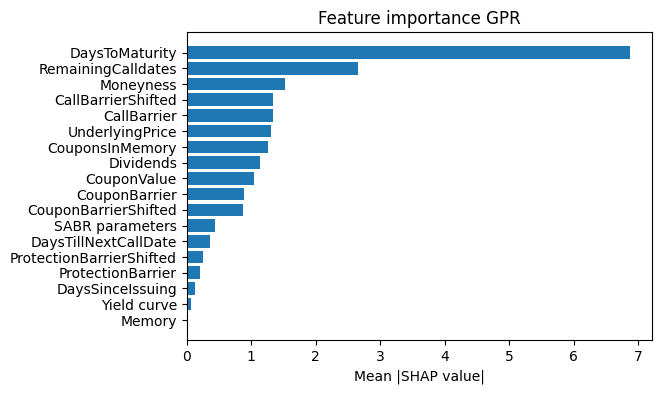

In [6]:
import shap

model = pd.read_pickle("models/gpr_full_model_tuned2.pkl")  

# explainer = shap.Explainer(model.predict, X_train_val)  # background data
# shap_values = explainer(X_test.sample(400, random_state=42))                     # compute SHAP on test set


sim_df = pd.read_pickle(
    r"C:\Users\14gij\OneDrive\Documenten\1 Master\Thesis\thesis code\ML Training\feature_files\sim_features_large3_2025-07-21"
)
sim_df = sim_df.dropna()

# Define target (y) and features (X)
y_sim_test = sim_df['Price']
X_sim_test = sim_df.drop(columns=['Price', 'Date']) 

explainer = shap.Explainer(model.predict, X)  # background data
shap_values = explainer(X_sim_test.iloc[:300])    #.sample(400, random_state=42)
#shap.summary_plot(shap_values, X_test, plot_type = "bar", show= True)  # 


import itertools
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 1. Which columns belong to which logical group?
yield_cols = ['1BD', '1WK', '1MO', '2MO', '6MO', '12MO',
              '2YR', '3YR', '4YR', '5YR', '7YR']
sabr_cols  = ['AlphaA', 'AlphaB', 'AlphaC',
              'RhoA', 'RhoB', 'RhoC',
              'NuB',  'NuC']
div_cols   = ['q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7']

group_dict = {
    'Yield curve' : yield_cols,
    'SABR parameters'   : sabr_cols,
    'Dividends'   : div_cols,
}

all_cols = list(X_sim_test.columns)

# ----------------------------------------------------------------------
# 2. Aggregate SHAP values for the *defined* groups
group_importance = {}
for gname, gcols in group_dict.items():
    idx = [all_cols.index(c) for c in gcols]
    group_importance[gname] = np.abs(shap_values.values[:, idx]).mean()

# ----------------------------------------------------------------------
# 3. OPTIONAL: keep only features that are NOT in any group
#     (Skip this entire block if you do not want singletons at all.)
grouped_features = set(itertools.chain.from_iterable(group_dict.values()))

for c in all_cols:
    if c not in grouped_features:
        group_importance[c] = np.abs(
            shap_values.values[:, all_cols.index(c)]
        ).mean()

# ----------------------------------------------------------------------
# 4. Plot the result
group_importance = dict(
    sorted(group_importance.items(), key=lambda kv: kv[1], reverse=True)
)

plt.figure(figsize=(6, 4))
plt.barh(list(group_importance.keys()), list(group_importance.values()))
plt.gca().invert_yaxis()
plt.xlabel('Mean |SHAP value|')
plt.title('Feature importance GPR')
plt.show()

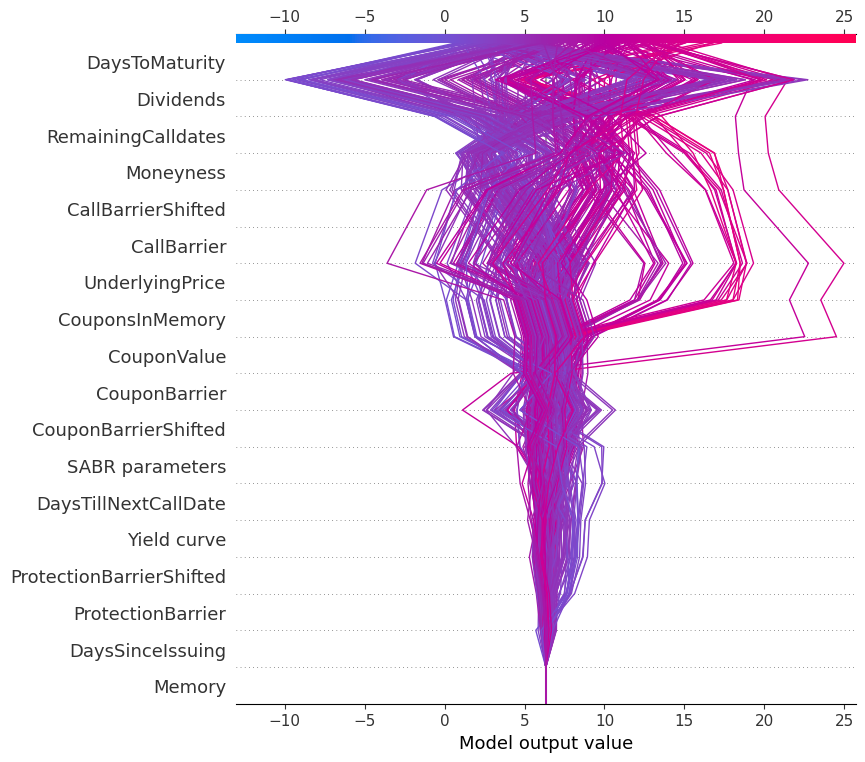

In [7]:
# --- SHAP decision plot with grouped features for a subsample of the first 200 observations ---
import numpy as np
import itertools

# 1) Build groups using your existing group_dict and add singletons
all_cols = list(X_sim_test.columns)
grouped_features = set(itertools.chain.from_iterable(group_dict.values()))

group_to_idx = {
    gname: [all_cols.index(c) for c in gcols if c in all_cols]
    for gname, gcols in group_dict.items()
}
for c in all_cols:
    if c not in grouped_features:
        group_to_idx[c] = [all_cols.index(c)]

group_names = list(group_to_idx.keys())

# 2) Aggregate SHAP values per group for ALL samples -> [n_samples x n_groups]
sv = shap_values.values  # shape: [n_samples x n_features]
group_sv_mat = np.column_stack([
    sv[:, idxs].sum(axis=1) if len(idxs) > 1 else sv[:, idxs[0]]
    for idxs in group_to_idx.values()
])

# 3) Order groups by global importance (mean |SHAP|) for cleaner plotting
order = np.argsort(np.mean(np.abs(group_sv_mat), axis=0))
group_sv_mat = group_sv_mat[:, order]
group_names_ordered = [group_names[j] for j in order]

# 4) Subsample the first 200 observations (avoid very large, slow plot)
idx = np.arange(min(200, group_sv_mat.shape[0]))

# 5) Use a scalar base value (average of base values across samples)
base_value_scalar = float(np.mean(shap_values.base_values))

# 6) Decision plot showing grouped paths for the subsample
shap.decision_plot(
    base_value=base_value_scalar,
    shap_values=group_sv_mat, #[idx, :]
    feature_names=group_names_ordered,
    link="identity",
    show=True
)


In [13]:


df_test = X_sim_test.copy()
df_test["target"] = y_sim_test                   


mask_edge = (
    (df_test["DaysTillNextCallDate"] < 25)
    | ((df_test["DaysTillNextCallDate"] >= 340)
       & (df_test["DaysTillNextCallDate"] <= 365))
)

mask_other = ~mask_edge                       

# split the test frame
test_edge  = df_test[mask_edge].reset_index(drop=True)
test_other = df_test[mask_other].reset_index(drop=True)

# split into X / y
X_test_edge,  y_test_edge  = test_edge.drop(columns="target"),  test_edge["target"]
X_test_other, y_test_other = test_other.drop(columns="target"), test_other["target"]

print(f"Edge-of-year (<20  or  340–365) : {len(X_test_edge)} samples")
print(f"Other                            : {len(X_test_other)} samples")

model = pd.read_pickle("models/gpr_full_model_tuned2.pkl")

predictions_edge = model.predict(X_test_edge)

r2_edge = r2_score(y_test_edge, predictions_edge)
avg_abs_error_edge = mean_absolute_error(y_test_edge, predictions_edge)
max_abs_error_edge = np.max(np.abs(y_test_edge - predictions_edge))
rmse_edge = root_mean_squared_error(y_test_edge, predictions_edge)
adjusted_mape_edge = np.mean(np.abs((y_test_edge - predictions_edge) / (max(y_test_edge) - min(y_test_edge)))) * 100

oos_metrics_edge = {
        "Average Absolute Error": avg_abs_error_edge,
        "Maximum Absolute Error": max_abs_error_edge,
        "Root Mean Squared Error": rmse_edge,
        "Adjusted MAPE (%)": adjusted_mape_edge,
        "r2": r2_edge
    }


predictions_other = model.predict(X_test_other)

r2_other = r2_score(y_test_other, predictions_other)
avg_abs_error_other = mean_absolute_error(y_test_other, predictions_other)
max_abs_error_other = np.max(np.abs(y_test_other - predictions_other))
rmse_other = root_mean_squared_error(y_test_other, predictions_other)
adjusted_mape_other = np.mean(np.abs((y_test_other - predictions_other) / (max(y_test_other) - min(y_test_other)))) * 100

oos_metrics_other = {
        "Average Absolute Error": avg_abs_error_other,
        "Maximum Absolute Error": max_abs_error_other,
        "Root Mean Squared Error": rmse_other,
        "Adjusted MAPE (%)": adjusted_mape_other,
        "r2": r2_other 
    }


print("\n========== out-sample  (edge-of-year) ==========")
print(oos_metrics_edge)

print("\n========== out-sample  (other) ================")
print(oos_metrics_other)

Edge-of-year (<20  or  340–365) : 396 samples
Other                            : 2164 samples

========== out-sample  (edge-of-year) ==========
{'Average Absolute Error': 0.5246641228550968, 'Maximum Absolute Error': 24.183250966332658, 'Root Mean Squared Error': 1.401958054043048, 'Adjusted MAPE (%)': 2.902597994519008, 'r2': 0.8678642825878373}

========== out-sample  (other) ================
{'Average Absolute Error': 0.6333598575951069, 'Maximum Absolute Error': 28.725659730842814, 'Root Mean Squared Error': 1.7990176853823516, 'Adjusted MAPE (%)': 1.420392233535233, 'r2': 0.8587987559360073}


In [ ]:

df_test = X_sim_test.copy()
df_test["target"] = y_sim_test   


delta        = (df_test["Moneyness"] * 100 - df_test["CallBarrier"]).abs()
diff_ratio   = delta / df_test["CallBarrier"]

mask_within5pct  = diff_ratio <= 0.05       # ≤ 5 %
mask_outside5pct = ~mask_within5pct         # > 5 %


test_within5pct  = df_test[mask_within5pct].reset_index(drop=True)
test_outside5pct = df_test[mask_outside5pct].reset_index(drop=True)

X_test_within5pct,  y_test_within5pct  = (
    test_within5pct.drop(columns="target"),  test_within5pct["target"]
)
X_test_outside5pct, y_test_outside5pct = (
    test_outside5pct.drop(columns="target"), test_outside5pct["target"]
)

print(f"Within 5 % of barrier : {len(X_test_within5pct)} samples")
print(f"Outside that range    : {len(X_test_outside5pct)} samples")


model = pd.read_pickle("models/gpr_full_model_tuned2.pkl")

predictions_within5pct = model.predict(X_test_within5pct)

r2_within = r2_score(y_test_within5pct, predictions_within5pct)
avg_abs_error_within5pct = mean_absolute_error(y_test_within5pct, predictions_within5pct)
max_abs_error_within5pct = np.max(np.abs(y_test_within5pct - predictions_within5pct))
rmse_within5pct = root_mean_squared_error(y_test_within5pct, predictions_within5pct)
adjusted_mape_within5pct = np.mean(np.abs((y_test_within5pct - predictions_within5pct) / (max(y_test_within5pct) - min(y_test_within5pct)))) * 100

oos_met_within5pct = {
        "Average Absolute Error": avg_abs_error_within5pct,
        "Maximum Absolute Error": max_abs_error_within5pct,
        "Root Mean Squared Error": rmse_within5pct,
        "Adjusted MAPE (%)": adjusted_mape_within5pct,
        "r2": r2_within   
    }


predictions_outside5pct = model.predict(X_test_outside5pct)

r2_outside = r2_score(y_test_outside5pct, predictions_outside5pct)
avg_abs_error_outside5pct = mean_absolute_error(y_test_outside5pct, predictions_outside5pct)
max_abs_error_outside5pct = np.max(np.abs(y_test_outside5pct - predictions_outside5pct))
rmse_outside5pct = root_mean_squared_error(y_test_outside5pct, predictions_outside5pct)
adjusted_mape_outside5pct = np.mean(np.abs((y_test_outside5pct - predictions_outside5pct) / (max(y_test_outside5pct) - min(y_test_outside5pct)))) * 100

oos_met_outside5pct = {
        "Average Absolute Error": avg_abs_error_outside5pct,
        "Maximum Absolute Error": max_abs_error_outside5pct,
        "Root Mean Squared Error": rmse_outside5pct,
        "Adjusted MAPE (%)": adjusted_mape_outside5pct,
        "r2": r2_outside 
    }


print("\n========== out-sample  |Δ|/Barrier ≤ 5 % ==========")
print(oos_met_within5pct)

print("\n========== out-sample  |Δ|/Barrier > 5 % ==========")
print(oos_met_outside5pct)

In [ ]:
# import optuna
# import numpy as np
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
# from sklearn.metrics import mean_squared_error
# from sklearn.model_selection import TimeSeriesSplit


# def tune_gpr(trainval_X, trainval_y,
#              n_trials=50, random_state=42, n_splits=5):
#     """
#     Tune GaussianProcessRegressor with Optuna using time-series cross-validation.
#     """
#     X, y = trainval_X, trainval_y         # keep original objects
#     cv = TimeSeriesSplit(n_splits=n_splits)

#     def objective(trial):
#         #length_scale = trial.suggest_float("length_scale", 1e-4, 1e3, log=True)
#         #constant_value = trial.suggest_float("constant_value", 1e-2, 1e4, log=True)
#         alpha = trial.suggest_float("alpha", 1e-10, 1e-1, log=True)

#         # kernel = C(constant_value=constant_value, constant_value_bounds="fixed") * RBF(length_scale=length_scale, length_scale_bounds= "fixed") 

#         kernel = C(1.0, (1e-2, 1e4)) * RBF(length_scale=1.0, length_scale_bounds= (1e-4, 1e3)) 

#         model = Pipeline([
#             ("scaler", StandardScaler()),
#             ("regressor", GaussianProcessRegressor(
#                 kernel=kernel,
#                 alpha=alpha,
#                 normalize_y=True,
#                 random_state=random_state
#             ))
#         ])

#         mses = []
#         for train_idx, valid_idx in cv.split(X):
#             model.fit(X.iloc[train_idx], y.iloc[train_idx])
#             preds = model.predict(X.iloc[valid_idx])
#             mses.append(mean_squared_error(y.iloc[valid_idx], preds))

#         return float(np.mean(mses))

#     study = optuna.create_study(direction="minimize")
#     study.optimize(objective, n_trials=n_trials)

#     best_params = study.best_params

#     # best_kernel = C(constant_value=best_params["constant_value"], constant_value_bounds="fixed") * RBF(length_scale=best_params["length_scale"],
#     #                                         length_scale_bounds= "fixed")
    
#     best_kernel = C(1.0, (1e-2, 1e4)) * RBF(length_scale=1.0, length_scale_bounds= (1e-4, 1e3))

#     best_model = Pipeline([
#         ("scaler", StandardScaler()),
#         ("regressor", GaussianProcessRegressor(
#             kernel=best_kernel,
#             alpha=best_params["alpha"],
#             normalize_y=True,
#             random_state=random_state
#         ))
#     ])
#     best_model.fit(X, y)

#     print("Best kernel after training:", best_model.named_steps['regressor'].kernel_)

#     return best_model, best_params




In [ ]:

# import optuna
# import numpy as np
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
# from sklearn.metrics import mean_squared_error

# def tune_gpr(trainval_X, trainval_y, n_trials=50, valid_size=0.2, random_state=42):
#     """
#     Tune GaussianProcessRegressor with Optuna using a time-aware split and optional standardization.
#     """
#     n_samples = len(trainval_X)
#     split_index = int(n_samples * (1 - valid_size))

#     X_train, X_valid = trainval_X[:split_index], trainval_X[split_index:]
#     y_train, y_valid = trainval_y[:split_index], trainval_y[split_index:]

#     def objective(trial):
#         length_scale = trial.suggest_float("length_scale", 1e-2, 1e2, log=True)
#         alpha = trial.suggest_float("alpha", 1e-10, 1e-1, log=True)

#         # Use tunable kernel bounds
#         kernel = C(1.0, (1e-2, 1e2)) * RBF(length_scale=length_scale, length_scale_bounds=(1e-2, 1e2))

#         model = Pipeline([
#             ("scaler", StandardScaler()),
#             ("regressor", GaussianProcessRegressor(
#                 kernel=kernel,
#                 alpha=alpha,
#                 normalize_y=True,
#                 random_state=random_state
#             ))
#         ])

#         model.fit(X_train, y_train)
#         preds = model.predict(X_valid)
#         mse = mean_squared_error(y_valid, preds)
#         return mse

#     study = optuna.create_study(direction="minimize")
#     study.optimize(objective, n_trials=n_trials)

#     best_params = study.best_params

#     # Reconstruct kernel for final model with tunable bounds
#     best_kernel = C(1.0, (1e-2, 1e2)) * RBF(length_scale=best_params["length_scale"], length_scale_bounds=(1e-2, 1e2))
#     best_model = Pipeline([
#         ("scaler", StandardScaler()),
#         ("regressor", GaussianProcessRegressor(
#             kernel=best_kernel,
#             alpha=best_params["alpha"],
#             normalize_y=True,
#             random_state=random_state
#         ))
#     ])
#     best_model.fit(trainval_X, trainval_y)

#     # Print the actual learned kernel (after training)
#     print("Best kernel after training:", best_model.named_steps['regressor'].kernel_)

#     return best_model, best_params

In [ ]:
# from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
# from scipy.stats import skew, kurtosis, jarque_bera
# import numpy as np


# def evaluate_gpr_model_from_params(X_train_val, y_train_val,
#                                    X_test, y_test, random_state=42):  #best_params
#     """
#     Evaluate GaussianProcessRegressor using best hyperparameters.
#     """
#     # kernel = C(constant_value=best_params["constant_value"], constant_value_bounds="fixed") * RBF(length_scale=best_params["length_scale"],
#     #                                    length_scale_bounds= "fixed") 

#     kernel = C(1.0, (1e-2, 1e4)) * RBF(length_scale=1.0, length_scale_bounds= (1e-4, 1e3)) + WhiteKernel(noise_level=1e-2, noise_level_bounds= (1e-10, 1e1))

#     model = Pipeline([
#         ("scaler", StandardScaler()),
#         ("regressor", GaussianProcessRegressor(
#             kernel=kernel,
#             # alpha=best_params["alpha"],
#             normalize_y=True,
#             random_state=random_state
#         ))
#     ])
#     model.fit(X_train_val, y_train_val)
#     predictions = model.predict(X_test)

#     epsilon = 1e-8
#     errors = y_test - predictions
#     mean_error = np.mean(errors)
#     std_error = np.std(errors, ddof=1)
#     skewness_error = skew(errors, bias=False)
#     kurtosis_error = kurtosis(errors, fisher=False, bias=False)
#     jb_stat, jb_p = jarque_bera(errors)

#     return {
#         "Average Absolute Error": mean_absolute_error(y_test, predictions),
#         "Maximum Absolute Error": np.max(np.abs(y_test - predictions)),
#         "Root Mean Squared Error": root_mean_squared_error(y_test, predictions),
#         "Mean Absolute Percentage Error (%)": np.mean(np.abs((y_test - predictions) / (y_test + epsilon))) * 100,
#         "Adjusted MAPE (%)": np.mean(np.abs((y_test - predictions) / (max(y_test) - min(y_test)))) * 100,
#         "Out of Sample R2": r2_score(y_test, predictions),
#         "Mean Error": mean_error,
#         "Std Dev Error": std_error,
#         "Skewness": skewness_error,
#         "Kurtosis": kurtosis_error,
#         "Jarque-Bera Statistic": jb_stat,
#         "Jarque-Bera p-value": jb_p,
#         "Pricing Errors": errors
#     }

In [ ]:
# import pickle
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# def save_gpr_model(best_params, X, y, save_path="trained_gpr_model.pkl", random_state=42):
#     """
#     Trains a GaussianProcessRegressor on the full dataset and saves it to disk using pickle.

#     Parameters:
#     best_params (dict): Dictionary with 'length_scale' and 'alpha'.
#     X (DataFrame): Full feature set (e.g. training + test).
#     y (Series): Full target set (aligned with X).
#     save_path (str): Path to save the trained model.
#     random_state (int): Seed for reproducibility.

#     Returns:
#     None
#     """
#     # kernel = C(constant_value=best_params["constant_value"], constant_value_bounds="fixed") * RBF(length_scale=best_params["length_scale"], length_scale_bounds= "fixed")
#     kernel = C(1.0, (1e-2, 1e4)) * RBF(length_scale=1.0, length_scale_bounds= (1e-4, 1e3)) 

#     model = Pipeline([
#         ("scaler", StandardScaler()),
#         ("regressor", GaussianProcessRegressor(
#             kernel=kernel,
#             alpha=best_params["alpha"],
#             normalize_y=True,
#             random_state=random_state
#         ))
#     ])
#     model.fit(X, y)

#     with open(save_path, "wb") as f:
#         pickle.dump(model, f)

#     print(f"GPR model trained on full data and saved to {save_path}")
#     print("Learned kernel:", model.named_steps['regressor'].kernel_)

In [5]:
# best_model, best_params = tune_gpr(X_train_val, y_train_val, n_trials=50)
# metrics = evaluate_gpr_model_from_params(X_train_val, y_train_val, X_test, y_test)
# print(metrics)

# save_gpr_model(best_params, X, y, save_path="models/gpr_full_model_firsttry.pkl")

[I 2025-07-16 13:43:22,492] A new study created in memory with name: no-name-3c2b8f49-c201-4e92-9f90-aae6d4e83c7f
[I 2025-07-16 13:43:47,214] Trial 0 finished with value: 2.9849302714645973 and parameters: {'alpha': 0.011812848617247934}. Best is trial 0 with value: 2.9849302714645973.
[I 2025-07-16 13:44:58,687] Trial 1 finished with value: 2.971785911971417 and parameters: {'alpha': 0.011886620825200376}. Best is trial 1 with value: 2.971785911971417.
[I 2025-07-16 13:45:43,085] Trial 2 finished with value: 3.9967678988788 and parameters: {'alpha': 1.0692516096958005e-08}. Best is trial 1 with value: 2.971785911971417.
[I 2025-07-16 13:46:39,287] Trial 3 finished with value: 3.979907323102085 and parameters: {'alpha': 0.00010055721552196634}. Best is trial 1 with value: 2.971785911971417.
[I 2025-07-16 13:47:23,247] Trial 4 finished with value: 3.9926896107225573 and parameters: {'alpha': 1.978114223230441e-05}. Best is trial 1 with value: 2.971785911971417.
[I 2025-07-16 13:48:05,43

Best kernel after training: 12.6**2 * RBF(length_scale=25.4)
{'Average Absolute Error': 1.9000777062334746, 'Maximum Absolute Error': 7.167623429193624, 'Root Mean Squared Error': 2.43878135057566, 'Mean Absolute Percentage Error (%)': 40.913428115228115, 'Adjusted MAPE (%)': 6.012723724472301, 'Out of Sample R2': 0.8443124312358807, 'Mean Error': 1.7345312392962908, 'Std Dev Error': 1.7160375897794211, 'Skewness': 0.5861051342060296, 'Kurtosis': 3.245778340717219, 'Jarque-Bera Statistic': 30.406682550706375, 'Jarque-Bera p-value': 2.4961620583052563e-07, 'Pricing Errors': 225    -0.093475
1133   -0.390816
1174   -0.158677
311    -0.472626
1967    0.247355
          ...   
902     0.093247
903     0.644152
904     0.613983
905     0.359554
906     1.531168
Name: Price, Length: 514, dtype: float64}
GPR model trained on full data and saved to models/gpr_full_model_firsttry.pkl
Learned kernel: 14.5**2 * RBF(length_scale=26.6)


In [ ]:
# save_gpr_model(best_params, X, y, save_path="models/gpr_full_model.pkl")

In [ ]:
# import optuna
# import numpy as np
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
# from sklearn.metrics import mean_squared_error

# def tune_gpr(trainval_X, trainval_y, n_trials=50, valid_size=0.2, random_state=42):
#     """
#     Tune GaussianProcessRegressor with Optuna using a time-aware split and optional standardization.

#     Parameters:
#         trainval_X (array-like): Features, ordered in time if time series.
#         trainval_y (array-like): Targets.
#         n_trials (int): Number of Optuna trials.
#         valid_size (float): Fraction of data for validation.
#         random_state (int): Seed.

#     Returns:
#         best_model (Pipeline): Trained Pipeline with StandardScaler + GPR.
#         best_params (dict): Best hyperparameters found by Optuna.
#     """
#     n_samples = len(trainval_X)
#     split_index = int(n_samples * (1 - valid_size))

#     X_train, X_valid = trainval_X[:split_index], trainval_X[split_index:]
#     y_train, y_valid = trainval_y[:split_index], trainval_y[split_index:]

#     def objective(trial):
#         length_scale = trial.suggest_float("length_scale", 1e-2, 1e2, log=True)
#         alpha = trial.suggest_float("alpha", 1e-10, 1e-1, log=True)

#         kernel = C(1.0, constant_value_bounds="fixed") * RBF(length_scale=length_scale)

#         model = Pipeline([
#             ("scaler", StandardScaler()),
#             ("regressor", GaussianProcessRegressor(kernel=kernel, alpha=alpha, normalize_y=True, random_state=random_state))
#         ])

#         model.fit(X_train, y_train)
#         preds = model.predict(X_valid)
#         rmse = mean_squared_error(y_valid, preds, squared=False)
#         return rmse

#     study = optuna.create_study(direction="minimize")
#     study.optimize(objective, n_trials=n_trials)

#     best_params = study.best_params

#     # Final model: trained on all data
#     best_kernel = C(1.0, constant_value_bounds="fixed") * RBF(length_scale=best_params["length_scale"])
#     best_model = Pipeline([
#         ("scaler", StandardScaler()),
#         ("regressor", GaussianProcessRegressor(kernel=best_kernel, alpha=best_params["alpha"], normalize_y=True, random_state=random_state))
#     ])
#     best_model.fit(trainval_X, trainval_y)

#     return best_model, best_params

# from sklearn.metrics import mean_absolute_error, mean_squared_error
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
# import numpy as np

# def evaluate_gpr_model_from_params(best_params, X_train_val, y_train_val, X_test, y_test, random_state=42):
#     """
#     Evaluate GaussianProcessRegressor using best hyperparameters.
#     """
#     kernel = C(1.0, constant_value_bounds="fixed") * RBF(length_scale=best_params["length_scale"])

#     model = Pipeline([
#         ("scaler", StandardScaler()),
#         ("regressor", GaussianProcessRegressor(
#             kernel=kernel,
#             alpha=best_params["alpha"],
#             normalize_y=True,
#             random_state=random_state
#         ))
#     ])
#     model.fit(X_train_val, y_train_val)
#     predictions = model.predict(X_test)

#     epsilon = 1e-8
#     y_test_safe = np.where(np.abs(y_test) < 1e-2, 1e-2, y_test)

#     return {
#         "Average Absolute Error": mean_absolute_error(y_test, predictions),
#         "Maximum Absolute Error": np.max(np.abs(y_test - predictions)),
#         "Root Mean Squared Error": mean_squared_error(y_test, predictions, squared=False),
#         "Mean Absolute Percentage Error (%)": np.mean(np.abs((y_test - predictions) / (y_test + epsilon))) * 100,
#         "Adjusted MAPE (%)": np.mean(np.abs((y_test - predictions) / y_test_safe)) * 100
#     }

# import pickle
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# def save_gpr_model(best_params, X, y, save_path="trained_gpr_model.pkl", random_state=42):
#     """
#     Trains a GaussianProcessRegressor on the full dataset and saves it to disk using pickle.

#     Parameters:
#     best_params (dict): Dictionary with 'length_scale' and 'alpha'.
#     X (DataFrame): Full feature set (e.g. training + test).
#     y (Series): Full target set (aligned with X).
#     save_path (str): Path to save the trained model.
#     random_state (int): Seed for reproducibility.

#     Returns:
#     None
#     """
#     kernel = C(1.0, constant_value_bounds="fixed") * RBF(length_scale=best_params["length_scale"])

#     model = Pipeline([
#         ("scaler", StandardScaler()),
#         ("regressor", GaussianProcessRegressor(
#             kernel=kernel,
#             alpha=best_params["alpha"],
#             normalize_y=True,
#             random_state=random_state
#         ))
#     ])
#     model.fit(X, y)

#     with open(save_path, "wb") as f:
#         pickle.dump(model, f)

#     print(f"GPR model trained on full data and saved to {save_path}")

# from sklearn.metrics import mean_absolute_error, root_mean_squared_error
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
# import numpy as np

# def evaluate_gpr_model_from_params(best_params, X_train_val, y_train_val, X_test, y_test, random_state=42):
#     """
#     Evaluate GaussianProcessRegressor using best hyperparameters.
#     """
#     kernel = C(1.0, (1e-2, 1e2)) * RBF(length_scale=best_params["length_scale"], length_scale_bounds=(1e-2, 1e2))

#     model = Pipeline([
#         ("scaler", StandardScaler()),
#         ("regressor", GaussianProcessRegressor(
#             kernel=kernel,
#             alpha=best_params["alpha"],
#             normalize_y=True,
#             random_state=random_state
#         ))
#     ])
#     model.fit(X_train_val, y_train_val)
#     predictions = model.predict(X_test)

#     epsilon = 1e-8
#     y_test_safe = np.where(np.abs(y_test) < 1e-2, 1e-2, y_test)

#     return {
#         "Average Absolute Error": mean_absolute_error(y_test, predictions),
#         "Maximum Absolute Error": np.max(np.abs(y_test - predictions)),
#         "Root Mean Squared Error": root_mean_squared_error(y_test, predictions),
#         "Mean Absolute Percentage Error (%)": np.mean(np.abs((y_test - predictions) / (y_test + epsilon))) * 100,
#         "Adjusted MAPE (%)": np.mean(np.abs((y_test - predictions) / y_test_safe)) * 100
#     }


# sim_df = pd.read_pickle("C:/Users/UGGROO/OneDrive - Van Lanschot Kempen/Documents/MSc Thesis/3. Repos/thesis code/ML Training/feature_files/sim_features_2025-06-11")

# # Define target (y) and features (X)
# y_sim_test = sim_df['Price']
# X_sim_test = sim_df.drop(columns=['Price', 'Date'])  # Exclude Date from features

# model = pd.read_pickle("models/gpr_full_model.pkl")

# predictions = model.predict(X_sim_test)

# avg_abs_error = mean_absolute_error(y_sim_test, predictions)
# max_abs_error = np.max(np.abs(y_sim_test - predictions))
# rmse = root_mean_squared_error(y_sim_test, predictions)

# epsilon = 1e-8
# mape = np.mean(np.abs((y_sim_test - predictions) / (y_sim_test + epsilon))) * 100
# y_test_safe = np.where(np.abs(y_sim_test) < 1e-2, 1e-2, y_sim_test)
# adjusted_mape = np.mean(np.abs((y_sim_test - predictions) / y_test_safe)) * 100

# print({
#         "Average Absolute Error": avg_abs_error,
#         "Maximum Absolute Error": max_abs_error,
#         "Root Mean Squared Error": rmse,
#         "Mean Absolute Percentage Error (%)": mape,
#         "Adjusted MAPE (%)": adjusted_mape
#     })